# Code for plots in Fig.5

In [4]:
# import libraries
import numpy as np
import matplotlib as mpl
mpl.use("Qt5Agg")
import matplotlib.pyplot as plt
import os,sys,inspect
from scipy.stats import stats,levene,shapiro,ttest_ind,mannwhitneyu
from statsmodels.stats.multitest import multipletests
%matplotlib inline

# import modules
from pseudopopulation_intime import Single_var
currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0,parentdir)

from utilities import compute_pvalues_trace,plot_pvalues_trace,format_violinplot,statistical_annotation

## Fig 5A, 5B, 5C, 5D (left)

Corresponds to schematic illustrations

## Fig 5D (right)
### Decoding of category, choice and outcome in trial time.

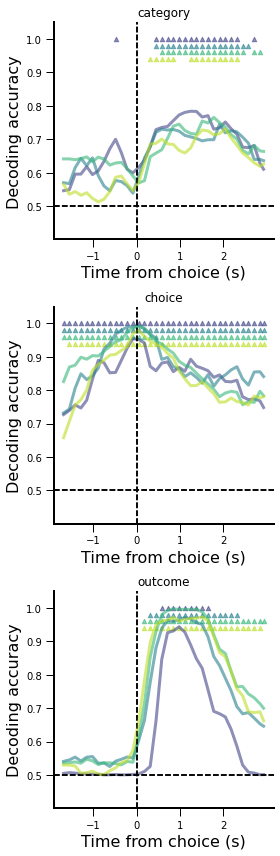

In [16]:
def pseudopop_intime(event_align='choice'):
    '''
    panel with phases x variables for each alignment
    pseudopopulation 
    '''
    variables = ['category', 'choice', 'outcome']
    phases = ['discrimination','gentest_1','categorization_4','gentest_2']
    label_dict = {
        'discrimination':'DISC',
        'gentest_1':'GT_1',
        'categorization_4':'CAT',
        'gentest_2':'GT_2'}
    
    colors = plt.cm.viridis(np.linspace(0.2,0.9,len(phases)))
    
    fig,axs = plt.subplots(len(variables),1)
    fig.set_figwidth(4)
    fig.set_figheight(4*len(variables))
    
    for i,v in enumerate(variables):
        for phase in phases:
            color_idx = phases.index(phase)
            
            entry = Single_var()\
                & 'experimental_timepoint="%s"'%phase & 'variable="%s"'%v \
                    & 'event_align="%s"'%event_align
                    
            timepoints = entry.fetch('timepoints')[0]
            null = entry.fetch('null')[0]
            acc = np.mean(entry.fetch('accuracies')[0],0)
            
            pvalues_acc = compute_pvalues_trace(acc,null,
                                          multiple_correction=True,method='max') 
            axs[i].plot(timepoints,acc,color=colors[color_idx],linewidth=3,alpha=0.6,
                          label = label_dict[phase])
            axs[i] = plot_pvalues_trace(axs[i],pvalues_acc,timepoints,
                                    1-color_idx*0.02,colors[color_idx],alpha=0.6)
            
            axs[i].set_ylabel('Decoding accuracy',fontsize=16)
            axs[i].axvline(x=0,linestyle='--',color='black',alpha=0.7)
            axs[i].axhline(y=0.5,linestyle='--',color='black',alpha=0.7)
            axs[i].set_ylim(0.4,1.05)
            axs[i].set_yticks(np.arange(0.5,1.05,0.1))
            axs[i].set_xticks(np.arange(int(timepoints[0]),int(timepoints[-1])+0.5,1))
            axs[i].spines["top"].set_visible(False)
            axs[i].spines["right"].set_visible(False)
            axs[i].spines["bottom"].set_linewidth(2)
            axs[i].spines["left"].set_linewidth(2)
            axs[i].tick_params(size= 8,width=1, length=10)
            axs[i].set_title(v)
 
    for ax in axs:
        ax.set_xlabel('Time from %s (s)'%event_align,fontsize=16)
    plt.tight_layout()
    plt.show()
    
pseudopop_intime()

## Fig 5E (right) 
### Integrated decoding accuracy in post-choice window

Overall test:  Kruskall-Wallis test
Var: category p:  2.314102214550398e-45
Var: choice p:  4.0456289440058443e-19
Var: outcome p:  4.080847270811259e-72
#### Var: category
mann whitney (non-corrected) p: 2.751283163690927e-27
DISC  vs  GT_1 True
mann whitney (non-corrected) p: 4.2089417656750626e-24
DISC  vs  CAT True
mann whitney (non-corrected) p: 3.969716060228523e-30
DISC  vs  GT_2 True
mann whitney (non-corrected) p: 0.6190268600882094
GT_1  vs  CAT False
mann whitney (non-corrected) p: 8.488531323620425e-13
GT_1  vs  GT_2 True
mann whitney (non-corrected) p: 2.707188352279721e-09
CAT  vs  GT_2 True
#### Var: choice
mann whitney (non-corrected) p: 0.0029082837314014683
DISC  vs  GT_1 True
mann whitney (non-corrected) p: 5.960589913727165e-12
DISC  vs  CAT True
mann whitney (non-corrected) p: 0.14164345203833323
DISC  vs  GT_2 False
mann whitney (non-corrected) p: 8.51305004731366e-06
GT_1  vs  CAT True
mann whitney (non-corrected) p: 2.5115641120403476e-06
GT_1  vs  GT_2 True
man

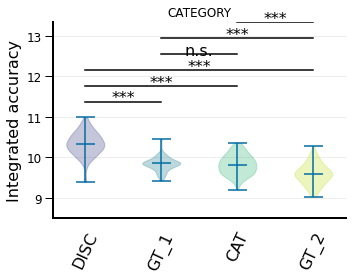

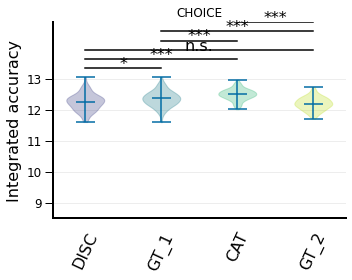

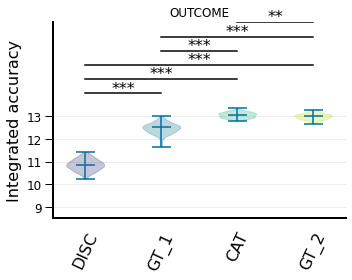

In [6]:
def acc_auc(event_align='choice'):
    
    '''
    plot of integrated decoding accuraccy in trial time
    across stages for all variables
    '''
    variables = ['category','choice','outcome']
    
    nr_crossval = 100
    column_labels = ['DISC', 'GT_1', 'CAT', 'GT_2']
    
    var_window = np.array([[0,2],
                  [0,2],
                  [0,2]])
    
    phases = ['discrimination','gentest_1','categorization_4','gentest_2']
    nr_phases = len(phases)
    colors = plt.cm.viridis(np.linspace(0.2,0.9,len(phases)))
    data_auc = np.zeros((len(variables),len(phases),nr_crossval)) 
    xvals = np.arange(0,len(phases),1)
    
    for i,v in enumerate(variables):
        for j,phase in enumerate(phases):
            entry = Single_var()\
                & 'experimental_timepoint="%s"'%phase & 'variable="%s"'%v \
                    & 'event_align="%s"'%event_align 
    
            acc = entry.fetch('accuracies')[0]
            timepoints = entry.fetch('timepoints')[0]
            # take timepoints in the specified window
            w_idx = [var_window[i,0],var_window[i,1]]
            t_idx = [np.where(timepoints>w_idx[0])[0][0],
                      np.where(timepoints>w_idx[1])[0][0]]
            
            # compute auc of traces
            data_auc[i,j] = np.trapz(acc[:,t_idx[0]:t_idx[1]],axis=1)
            
    # check assumptions of anova  -> default to kruskal wallis test
    
    # levene test to check for homogeneity of variances
    homogeneity = True
    for i,v in enumerate(variables):
        
        res = levene(data_auc[i,0],
                   data_auc[i,1],
                   data_auc[i,2],
                   data_auc[i,3])
        if res.pvalue < 0.05:
            homogeneity = False
            break
        
    test = 'One way Anova' # one factor stage, with four levels

    # check normality
    normality = True
    for i,v in enumerate(variables):
        for j,phase in enumerate(phases):
            shapiro_test = shapiro(data_auc[i,j])
            
            if shapiro_test.pvalue < 0.05:
                normality = False
                break
        
    if normality and homogeneity:
        test = 'One way Anova test'
    else:
        test = 'Kruskall-Wallis test'
    
    print('Overall test: ',test)
    
    var_pval_ao = []
    for i,v in enumerate(variables):
            
        if normality and homogeneity:
            # one way anova
            res = stats.f_oneway(data_auc[i,0],
                   data_auc[i,1],
                   data_auc[i,2],
                   data_auc[i,3])
            pval = res.pvalue
            print('Var: %s p: '%v,pval)
            
            # # transform data to pandas dataframe
            data = np.concatenate(data_auc[i])
            stage_col = np.repeat(np.arange(nr_phases), nr_crossval)
            data_df = np.vstack((data,stage_col)).T
            df = pd.DataFrame(data_df, columns=['auc', 'stage'])
    
            # check normality of residues of model
            model = ols('auc ~ C(stage)-1', data=df).fit()
            
            # model.pvalue,   model.model.exog_names
            _,resid_pval = shapiro(model.resid)
            print('normality residue: ',resid_pval>0.05)
            
            
        else:
            # kruskal wallis
            res = stats.kruskal(data_auc[i,0],
                   data_auc[i,1],
                   data_auc[i,2],
                   data_auc[i,3])
            pval = res.pvalue
            
            print('Var: %s p: '%v,pval)
        
        var_pval_ao.append(pval)
        
    # if signigicant check post hoc testing comparisons t test
    # with alpha bonferroni correction
    comparisons = []
    for j,phase in enumerate(phases):
        for k in range(j,len(phases)):
            if j!=k:
                comparisons.append([j,k])
    
    for i,v in enumerate(variables):
        # color = np.repeat([colors[i]],3) 
        fig, axs = plt.subplots()
        fig.set_figheight(4)
        fig.set_figwidth(5)
        format_violinplot(axs,data_auc[i].T,column_labels,colors=colors)
        
        if var_pval_ao[i] < 0.05:
            print('#### Var: %s'%v)
            # check all comparisons
            comparison_pvals = []
            for c,comparison in enumerate(comparisons):
                col1,col2 = comparison
                
                if normality:
                    stat,p_value = ttest_ind(data_auc[i,col1],data_auc[i,col2],
                                             alternative='two-sided')
                    print('t test (non-corrected) p: %s'%p_value)
                else:
                    stat,p_value = mannwhitneyu(data_auc[i,col1],data_auc[i,col2],
                                                alternative='two-sided')
                    print('mann whitney (non-corrected) p: %s'%p_value)
                # correction for multiple comparisons
                print(column_labels[col1],' vs ',column_labels[col2],p_value<(0.05/len(comparisons)))
                comparison_pvals.append(p_value)
                
            # correction for multiple comparisons
            _, comparison_pvals, _, _ = multipletests(comparison_pvals, method='bonferroni')
            
            ymax = data_auc[i].max(); ymin = data_auc[i].min()
            axs,ymaxlim = statistical_annotation(axs,comparisons,
                                         comparison_pvals,ymax,ymin)
            
            axs.set_xticks(xvals)
            axs.set_xticklabels(column_labels,rotation=65, fontsize = 16)
            axs.spines["top"].set_visible(False)
            axs.spines["right"].set_visible(False)
            axs.spines["bottom"].set_linewidth(2)
            axs.spines["left"].set_linewidth(2)
            # axs.legend()
            axs.tick_params(size= 8,width=1, length=10) # labelsize = labelsize
            axs.set_ylim(8.5,ymaxlim)
            axs.set_yticks(np.arange(9,14,1))
            axs.set_ylabel('Integrated accuracy',fontsize=16)
            axs.set_title(v.upper())
            plt.tight_layout()
            
acc_auc()